Importar las Librerías

In [1]:
import csv
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

Lectura de los datos

In [2]:
with open('data/BBC-News/BBC-News-Train.csv', 'r') as csvfile:
    print(f"Primera Linea : {csvfile.readline()}")
    print(f"Cada fila con datos : {csvfile.readline()}")
    print(f"Cada fila con datos : {csvfile.readline()}")
    print(f"Cada fila con datos : {csvfile.readline()}")

Primera Linea : ArticleId,Text,Category

Cada fila con datos : 1833,worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness.  cynthia cooper  worldcom s ex-head of internal accounting  alerted directors to irregular accounting practices at the us telecoms giant in 2002. her warnings led to the collapse of the firm following the discovery of an $11bn (£5.7bn) accounting fraud. mr ebbers has pleaded not guilty to charges of fraud and conspiracy.  prosecution lawyers have argued that mr ebbers orchestrated a series of accounting tricks at worldcom  ordering employees to hide expenses and inflate revenues to meet wall street earnings estimates. but ms cooper  who now runs her own consulting business  told a jury in new york on wednesday that external auditors arthur andersen had approved worldcom s accounting in early 2001 and 2002. she said andersen had given a  gr

Como se aprecia se tiene un Id, Texto y el Label. Para esto el texto debe de tener sentido, palabras clave, ya que previamente se realizan stopwords (conectores, etc.). Palabras que deben estar juntas le aportarán ese contexto necesario para inferir otros contextos de similar categoría.

- El dataset se puede descargar de Kaggle agregando BBC News.
- Otro dataset interesante se llama: WSDM-KKBox Recomendation Challenge. Lo interesante de este tópico es que se tiene el codigo de referencia del desarrollador.

Función de Stopwords

En la siguiente función se tiene una lista de stopwrods definidos para un proyecto en inglés

In [3]:
def removeStopwords(sentence):
	stopwords = ["a", "about", "above", "after", "again", "against", "all", "am", "an", "and", "any", "are", "as", "at", "be", "because", "been", "before", "being", "below", "between", "both", "but", "by", "could", "did", "do", "does", "doing", "down", "during", "each", "few", "for", "from", "further", "had", "has", "have", "having", "he", "he'd", "he'll", "he's", "her", "here", "here's", "hers", "herself", "him", "himself", "his", "how", "how's", "i", "i'd", "i'll", "i'm", "i've", "if", "in", "into", "is", "it", "it's", "its", "itself", "let's", "me", "more", "most", "my", "myself", "nor", "of", "on", "once", "only", "or", "other", "ought", "our", "ours", "ourselves", "out", "over", "own", "same", "she", "she'd", "she'll", "she's", "should", "so", "some", "such", "than", "that", "that's", "the", "their", "theirs", "them", "themselves", "then", "there", "there's", "these", "they", "they'd", "they'll", "they're", "they've", "this", "those", "through", "to", "too", "under", "until", "up", "very", "was", "we", "we'd", "we'll", "we're", "we've", "were", "what", "what's", "when", "when's", "where", "where's", "which", "while", "who", "who's", "whom", "why", "why's", "with", "would", "you", "you'd", "you'll", "you're", "you've", "your", "yours", "yourself", "yourselves" ]
	sentence = sentence.lower()
	sentence = sentence.split(' ')
	for stopword in stopwords:
		try:
			while True:
				sentence.remove(stopword)
		except:
			pass
	sentence = ' '.join(sentence)
	return sentence

In [4]:
removeStopwords("I am about to go to the store and get any cookie")

'go store get cookie'

In [5]:
def convertirDatosDesdeTexto(archivo):
    sentences = []
    labels = []
    with open(archivo, 'r') as csvfile:
        reader = csv.reader(csvfile, delimiter='\n')
        first = True
        for fila in reader:
            if (first == False):
                #print("FILA:",fila)
                texto = fila[0].split(',')
                #print("TEXTO:",texto)
                etiqueta = texto[2]
                labels.append(etiqueta)
                sentences.append(removeStopwords(texto[1]))
            else:
                first = False
    return sentences, labels

In [6]:
sentences, labels = convertirDatosDesdeTexto('BBC-News/BBC-News-Train.csv')

print(f"Cantidad de registros {len(sentences)}")
print(f"Primera oracion : {len(sentences[0].split())}")
print(f"Cantidad de labels : {len(labels)}")

Cantidad de registros 1490
Primera oracion : 203
Cantidad de labels : 1490


In [7]:
sentences[1]

'german business confidence slides german business confidence fell february knocking hopes speedy recovery europe s largest economy.  munich-based research institute ifo said confidence index fell 95.5 february 97.5 january  first decline three months. study found outlook manufacturing retail sectors worsened. observers hoping confident business sector signal economic activity picking up.   re surprised ifo index taken knock   said dz bank economist bernd weidensteiner.  main reason probably domestic economy still weak  particularly retail trade.  economy labour minister wolfgang clement called dip february s ifo confidence figure  mild decline . said despite retreat  index remained relatively high level expected  modest economic upswing  continue.  germany s economy grew 1.6% last year shrinking 2003. however  economy contracted 0.2% last three months 2004  mainly due reluctance consumers spend. latest indications growth still proving elusive ifo president hans-werner sinn said improv

In [8]:
labels[1:10]

['business',
 'business',
 'tech',
 'business',
 'politics',
 'sport',
 'entertainment',
 'business',
 'entertainment']

In [9]:
def fitTokenizer(sentences):
    tokenizer = Tokenizer(num_words=1000, oov_token="<OOV>") #Transformar cada palabra en un numero
    tokenizer.fit_on_texts(sentences)
    return tokenizer

In [ ]:
tokenizer = fitTokenizer(sentences)
tokenizer.word_index
#OOV: Out of Vocabulary. Palabras que no estan en el diccionario

{'<OOV>': 1,
 's': 2,
 'said': 3,
 'will': 4,
 'not': 5,
 'mr': 6,
 'year': 7,
 'also': 8,
 'new': 9,
 'people': 10,
 'us': 11,
 'one': 12,
 'can': 13,
 'first': 14,
 'last': 15,
 'two': 16,
 'time': 17,
 'world': 18,
 't': 19,
 'now': 20,
 'uk': 21,
 'government': 22,
 'film': 23,
 'years': 24,
 'no': 25,
 'best': 26,
 'just': 27,
 'make': 28,
 'told': 29,
 'three': 30,
 'made': 31,
 'get': 32,
 'game': 33,
 'many': 34,
 'back': 35,
 '000': 36,
 'like': 37,
 'number': 38,
 '1': 39,
 'labour': 40,
 'set': 41,
 'music': 42,
 'next': 43,
 'well': 44,
 'bbc': 45,
 'may': 46,
 'take': 47,
 'added': 48,
 'way': 49,
 'market': 50,
 'election': 51,
 'says': 52,
 'home': 53,
 '2004': 54,
 '2': 55,
 'good': 56,
 'off': 57,
 'england': 58,
 'firm': 59,
 'win': 60,
 'still': 61,
 'top': 62,
 '6': 63,
 'company': 64,
 'blair': 65,
 'show': 66,
 'won': 67,
 'use': 68,
 'week': 69,
 'going': 70,
 'party': 71,
 'second': 72,
 'since': 73,
 'say': 74,
 'games': 75,
 'work': 76,
 'much': 77,
 'million'

In [ ]:
# Ejemplo de como se convierte una sentencia en numeros
ExampleTokenizer = tokenizer.texts_to_sequences("I am about to go to the store and get any cookie")
ExampleTokenizer

[[1],
 [],
 [1],
 [132],
 [],
 [1],
 [1],
 [229],
 [1],
 [19],
 [],
 [19],
 [229],
 [],
 [1],
 [229],
 [],
 [19],
 [229],
 [],
 [19],
 [1],
 [243],
 [],
 [2],
 [19],
 [229],
 [1],
 [243],
 [],
 [1],
 [1],
 [478],
 [],
 [1],
 [243],
 [19],
 [],
 [1],
 [1],
 [1],
 [],
 [1],
 [229],
 [229],
 [1],
 [1],
 [243]]

In [12]:
# Por cada sentencia: Cada palabra es representada por un numero definido por el tokenizer
def padSequences(tokenizer, sentences):
    sequences = tokenizer.texts_to_sequences(sentences)
    paddedSequences = pad_sequences(sequences, padding='post', maxlen=120) #120 es el padding. Si la sentencia es mas larga, se corta extrayendo los primeros 120 caracteres y si es mas corta, se agrega padding. 
    #¿Pregunta como corta es la sentencia?
    return paddedSequences

In [13]:
paddedSequencesExample = padSequences(tokenizer, sentences)

In [14]:
paddedSequencesExample[0].shape

(120,)

In [15]:

import numpy as np

def tokenizerLabels(labels, split_labels):
    labelTokenizer = Tokenizer()
    labelTokenizer.fit_on_texts(labels) #Se le pasa el diccionario total de palabras
    labelSequences = labelTokenizer.texts_to_sequences(split_labels) #Dado el total de labels aprendido en fit_on_texts se asigna un numero a los labels del set de datos (entrenamiento, validacion, etc.)
    print(labelTokenizer.word_index)
    labelSequences = np.array(labelSequences)-1 #Permite que los labels empiecen desde 0
    return labelSequences

# No se agrega un padding porque las etiquetas no tienen un maximo de palabras. Solo representa una categoria por cada sentencia
# Por lo tanto, se convierte cada etiqueta en un numero

In [16]:
TokenizarLabelExample = tokenizerLabels(labels, labels)

{'sport': 1, 'business': 2, 'politics': 3, 'entertainment': 4, 'tech': 5}


In [18]:
TokenizarLabelExample[0]

array([1])

In [19]:
def train_val_split(sentences, labels, training_split=0.8):
    train_size = int(len(sentences)*training_split)
    train_sentences = sentences[:train_size]
    train_labels = labels[:train_size]
    val_sentences = sentences[train_size:]
    val_labels = labels[train_size:]
    return train_sentences, val_sentences, train_labels, val_labels

In [20]:
train_sentences, val_sentences, train_labels, val_labels = train_val_split(sentences, labels)

In [21]:
train_sentences[0]

'worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers battery fraud charges called company whistleblower first witness.  cynthia cooper  worldcom s ex-head internal accounting  alerted directors irregular accounting practices us telecoms giant 2002. warnings led collapse firm following discovery $11bn (£5.7bn) accounting fraud. mr ebbers pleaded not guilty charges fraud conspiracy.  prosecution lawyers argued mr ebbers orchestrated series accounting tricks worldcom  ordering employees hide expenses inflate revenues meet wall street earnings estimates. ms cooper  now runs consulting business  told jury new york wednesday external auditors arthur andersen approved worldcom s accounting early 2001 2002. said andersen given  green light  procedures practices used worldcom. mr ebber s lawyers said unaware fraud  arguing auditors not alert problems.  ms cooper also said shareholder meetings mr ebbers often passed technical questions company s finance chief 

In [22]:
len(train_labels)

1192

In [23]:
len(labels)

1490

Se hace uso de las funciones

In [24]:
train_padd_seq = padSequences(tokenizer, train_sentences)
val_padd_seq = padSequences(tokenizer, val_sentences)

In [25]:
train_padd_seq[0]

array([509, 457,   1,   1,   1,   1,   1,   1,   2,   1, 234, 494, 608,
         3,   1, 220,   1,   1,   1,   1,  87,   1,   6,   1,   2,   1,
         3,   1, 629,   1,   1,   5,   1, 356, 369,   1,   8,   3,   1,
         1,   6,   1, 805,   1,   1,   1,  64,   2, 906, 136,   1,   1,
         1,   1,   1,   2, 219,   1, 121,   1, 262, 136,   1,   1,   3,
         6,   1,   1,   1,   1,  59,   1, 166,   1, 105, 369,   1,   3,
         6,   1,   5,   1, 860,   1,   1,   2,   1, 494,   1, 631, 388,
         6,   1, 314,   1,   1,   1,  24,   1, 725,   1,   1,   1, 957,
         1,  54,  20, 413,   1,  15,  69,   1, 546,   1,   1,   1, 125,
         1,  63,   1], dtype=int32)

In [26]:
# Los 1 son las palabras que no se han podido reconocer

In [27]:
train_label_seq = tokenizerLabels(labels, train_labels)
val_label_seq = tokenizerLabels(labels, val_labels)

{'sport': 1, 'business': 2, 'politics': 3, 'entertainment': 4, 'tech': 5}
{'sport': 1, 'business': 2, 'politics': 3, 'entertainment': 4, 'tech': 5}


In [28]:
print(train_padd_seq.shape)
print(val_padd_seq.shape)

(1192, 120)
(298, 120)


Entrenamiento del modelo

In [29]:
import tensorflow as tf

modelo = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=1000, output_dim=16, input_length=120), #Convierte cada palabra en un vector de 16 dimensiones #1000 es porque el tokenizer tiene 1000 palabras #120 es porque el padding es de 120 palabras
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(35, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])

/Users/larenwell/Documents/personal/projects/ai-dl-tensorflow-specialization-fabricum-pucp/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [30]:
modelo.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'])

In [31]:
#modelo.summary()

history=modelo.fit(
    train_padd_seq, 
    train_label_seq,
    epochs=35,
    validation_data=(val_padd_seq, val_label_seq),
    verbose=1)

Epoch 1/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3322 - loss: 1.6020 - val_accuracy: 0.2013 - val_loss: 1.5912
Epoch 2/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3540 - loss: 1.5696 - val_accuracy: 0.3758 - val_loss: 1.5508
Epoch 3/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 958us/step - accuracy: 0.4530 - loss: 1.5044 - val_accuracy: 0.4530 - val_loss: 1.4685
Epoch 4/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 978us/step - accuracy: 0.5361 - loss: 1.3921 - val_accuracy: 0.5470 - val_loss: 1.3396
Epoch 5/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step - accuracy: 0.6183 - loss: 1.2369 - val_accuracy: 0.6980 - val_loss: 1.1823
Epoch 6/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 992us/step - accuracy: 0.7727 - loss: 1.0644 - val_accuracy: 0.7819 - val_loss: 1.0074
Epoch 7/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8012 - loss: 0.8901 - val_accuracy: 0.8557 - val_loss: 0.8465
Epoch 8/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - accuracy: 0.8918 - loss: 0.7410 - val_accuracy: 0.8826 -

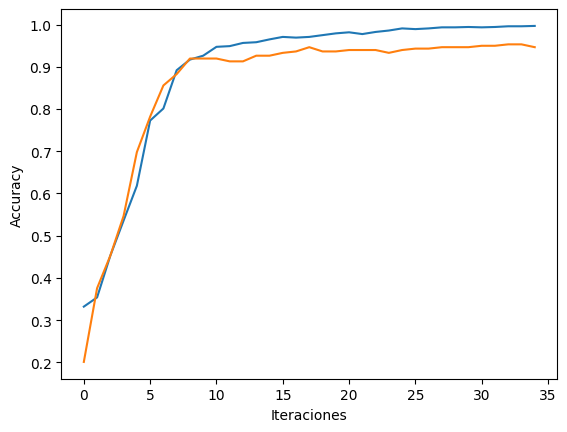

In [32]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Iteraciones')
plt.ylabel('Accuracy')
plt.show()

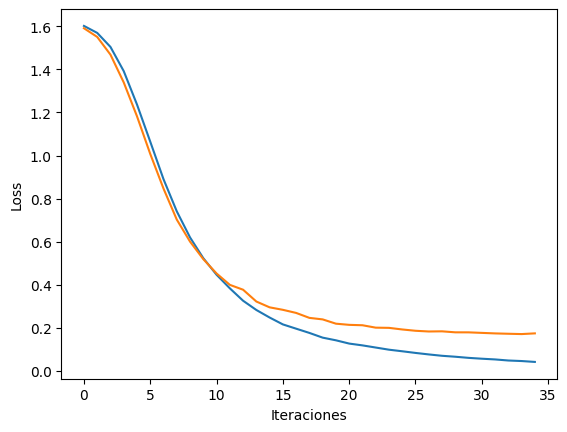

In [34]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.show()

In [ ]:
clases={0:'sport', 1:'business', 2:'politics', 4:'tech', 3:'entertainment'}



ejemplos = [
    "shares in the company fell in early trading after it said profits would be lower this year. analysts said the market reaction reflects concerns about future growth",
    "qpr keeper day heads for preston queens park rangers keeper chris day is set to join preston on a month s loan.  day has been displaced by the arrival of simon royce  who is in his second month on loan from charlton. qpr have also signed italian generoso rossi. r s manager ian holloway said:  some might say it s a risk as he can t be recalled during that month and simon royce can now be recalled by charlton.  but i have other irons in the fire. i have had a  yes  from a couple of others should i need them.   day s rangers contract expires in the summer. meanwhile  holloway is hoping to complete the signing of middlesbrough defender andy davies - either permanently or again on loan - before saturday s match at ipswich. davies impressed during a recent loan spell at loftus road. holloway is also chasing bristol city midfielder tom doherty",
    "the government said it will introduce new measures to improve public services. the minister said the policy aims to support economic growth and reduce unemployment",
    "technology firms said they are investing in new systems to improve services. the company said the platform will allow users to access data more quickly"
]

import numpy as np
def predecirTexto(texto):
    texto_padd = padSequences(tokenizer, [texto])
    probabilidades = modelo.predict(texto_padd)
    clase_idx = np.argmax(probabilidades, axis=1)[0] #Permite obtener el indice de la clase con la mayor probabilidad #El [0] es porque es una matriz de 1 fila y 5 columnas.Este comando permite obtener el indice de la columna con el valor mas alto
    return clases[clase_idx], probabilidades

for texto in ejemplos:
    clase, probabilidad = predecirTexto(texto)
    print(f"Texto: {texto}")
    print(f"Clase Predicha: {clase}")
    print(f"Probabilidad: {probabilidad.max():.4f}")
    print("--------------------------------")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Texto: shares in the company fell in early trading after it said profits would be lower this year. analysts said the market reaction reflects concerns about future growth
Clase Predicha: business
Probabilidad: 0.7992
--------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Texto: qpr keeper day heads for preston queens park rangers keeper chris day is set to join preston on a month s loan.  day has been displaced by the arrival of simon royce  who is in his second month on loan from charlton. qpr have also signed italian generoso rossi. r s manager ian holloway said:  some might say it s a risk as he can t be recalled during that month and simon royce can now be recalled by charlton.  but i have other irons in the fire. i have had a  yes  from a couple of others should i need them.   day s rangers contract expires in the summer. meanwhile  holloway is hoping to complete the signing of middlesbrough defender andy davies - either perman